In [1]:
# Insert plots into the notebook
%matplotlib inline

In [2]:
from __future__ import division, unicode_literals
import numpy as np
import multiprocessing
from IPython.display import Image
import matplotlib.pyplot as plt
import seaborn  # Makes the default style of the plots nicer

In [3]:
from fatiando.vis import mpl
from fatiando.gravmag import tesseroid
from fatiando import utils, gridder
import fatiando

d:\conda_envs\moho\lib\site-packages\fatiando\vis\mpl.py:76: UserWarning: This module will be removed in v0.6. We recommend the use of matplotlib.pyplot module directly. Some of the fatiando specific functions will remain.
  "specific functions will remain.")


In [4]:
print("Using Fatiando a Terra version: {}".format(fatiando.__version__))

Using Fatiando a Terra version: 0.5


In [5]:
from mohoinv import TesseroidRelief, MohoGravityInvSpherical, make_mesh

In [6]:
ncpu = multiprocessing.cpu_count()
ncpu

20

In [12]:
# shape is nlat, nlon = the number of points in the grid
shape = (30, 30)
# Make a regular grid inside an area = (s, n, w, e)
area = (20, 60, -40, 40)
lat, lon, h = gridder.regular(area, shape, z=40e3)
# Make a checkerboard relief undulating along the -35km height reference
f = 0.15
reference = -35e3
relief = 10e3*np.sin(1.5*f*lon)*np.cos(f*lat) + reference
# The density contrast is negative if the relief is below the reference
density = 600*np.ones_like(relief)
density[relief < reference] *= -1

In [13]:
model = make_mesh(area, shape, relief, reference)
model.addprop('density', density)

(19.310344827586206, 59.310344827586206)

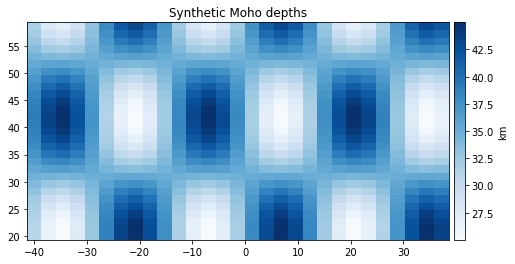

In [14]:
plt.figure(figsize=(9, 4))
plt.title("Synthetic Moho depths")
plt.pcolormesh(model.lons, model.lats, -0.001*model.relief.reshape(model.shape), 
               cmap='Blues')
plt.colorbar(pad=0.01).set_label('km')
plt.xlim(model.lons.min(), model.lons.max())
plt.ylim(model.lats.min(), model.lats.max())

In [15]:
gz = tesseroid.gz(lon, lat, h, model, njobs=ncpu)

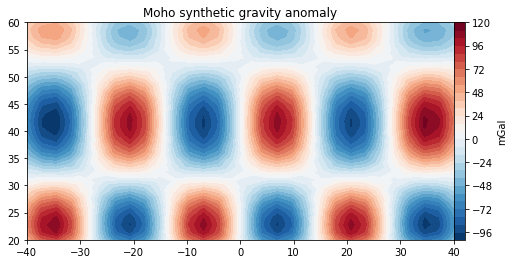

In [16]:
plt.figure(figsize=(9, 4))
plt.title('Moho synthetic gravity anomaly')
plt.tricontourf(lon, lat, gz, 30, cmap='RdBu_r')
plt.colorbar(pad=0).set_label('mGal')